<a href="https://colab.research.google.com/github/NamithaDaney/Bank_Marketing/blob/main/Bank_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split,GridSearchCV, RandomizedSearchCV, cross_val_score
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay


In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
#X = bank_marketing.data.features
#y = bank_marketing.data.targets


# Convert the dataset into a pandas DataFrame
df = pd.DataFrame(bank_marketing.data.features, columns=bank_marketing.feature_names)
df['target'] = bank_marketing.data.targets


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  target       45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [ ]:
bank_marketing.data.targets

,y
0,no
1,no
2,no
3,no
4,no
...,...
45206,yes
45207,yes
45208,yes
45209,no


In [ ]:
bank_marketing.data.features

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN


In [ ]:
# metadata
bank_marketing.metadata

{'uci_id': 222,
 'name': 'Bank Marketing',
 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing',
 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv',
 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).',
 'area': 'Business',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 45211,
 'num_features': 16,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'],
 'target_col': ['y'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 2014,
 'last_updated': 'Fri Aug 18 2023',
 'dataset_doi': '10.24432/C5K306',
 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'],
 'intro_paper': {'ID': 277,
  'type': 'NATIVE',
  'title': 'A data-driven a

In [ ]:
# variable information
bank_marketing.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,None,no
1,job,Feature,Categorical,Occupation,"type of job (categorical: 'admin.','blue-colla...",None,no
2,marital,Feature,Categorical,Marital Status,"marital status (categorical: 'divorced','marri...",None,no
3,education,Feature,Categorical,Education Level,"(categorical: 'basic.4y','basic.6y','basic.9y'...",None,no
4,default,Feature,Binary,None,has credit in default?,None,no
5,balance,Feature,Integer,None,average yearly balance,euros,no
6,housing,Feature,Binary,None,has housing loan?,None,no
7,loan,Feature,Binary,None,has personal loan?,None,no
8,contact,Feature,Categorical,None,contact communication type (categorical: 'cell...,None,yes
9,day_of_week,Feature,Date,None,last contact day of the week,None,no


In [ ]:
df.shape

(45211, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  target       45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


In [ ]:
#drop column poutcome. 81 per cent of data is nan so dropped the column
df.drop('poutcome', axis=1,inplace=True)

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'target'],
      dtype='object')

In [ ]:
#Numerical Columns
numerical_columns =[item for item in df.columns if df[item].dtype != 'O']
print(numerical_columns)

['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']


In [ ]:
#categorical columns
categorical_columns =[item for item in df.columns if df[item].dtype == 'O']
print(categorical_columns)

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'target']


In [ ]:
df['contact'].unique()

array([nan, 'cellular', 'telephone'], dtype=object)

In [ ]:
# Fill NaNs with mode value
df["contact"] = df["contact"].fillna(df["contact"].mode()[0])

In [ ]:
df['education'].unique()

array(['tertiary', 'secondary', nan, 'primary'], dtype=object)

In [ ]:
# Fill NaNs with mode value
df["education"] = df["education"].fillna(df["education"].mode()[0])

In [ ]:
df['job'].unique()

array(['management', 'technician', 'entrepreneur', 'blue-collar', nan,
       'retired', 'admin.', 'services', 'self-employed', 'unemployed',
       'housemaid', 'student'], dtype=object)

In [ ]:
# Fill NaNs with mode value
df['job'] = df['job'].fillna(df['job'].mode()[0])

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day_of_week,0


In [ ]:
#Univariate Analysis on Numerical Columns
for i in numerical_columns:
    print(i)
    skew = df[i].skew()
    kurt = df[i].kurtosis()
    print('Skewness \t:',round(skew,2))
    print('Kurtosis \t:',round(kurt,2))
    # Skewness Interpretation
    print("Mean   :", round(df[i].mean(), 2))
    print("Median :", round(df[i].median(), 2))
    print("Mode   :", round(df[i].mode()[0], 2))

    if skew > 1:
        print(f"{i} is highly right-skewed.")
    elif skew > 0.5:
        print(f"{i} is moderately right-skewed.")
    elif skew < -1:
        print(f"{i} is highly left-skewed.")
    elif skew < -0.5:
        print(f"{i} is moderately left-skewed.")
    else:
        print(f"{i} is approximately normally distributed.")

    # Kurtosis Interpretation
    if kurt > 3:
        print(f"The distribution indicates a high presence of outliers.")
    elif kurt > 0:
        print(f"The distribution suggests a moderate presence of outliers.")
    elif kurt > -1:
        print(f"The distribution contains few outliers.")
    else:
        print(f"The distribution shows very little to no presence of outliers.")

    print("-" * 100)


age
Skewness 	: 0.68
Kurtosis 	: 0.32
Mean   : 40.94
Median : 39.0
Mode   : 32
age is moderately right-skewed.
The distribution suggests a moderate presence of outliers.
----------------------------------------------------------------------------------------------------
balance
Skewness 	: 8.36
Kurtosis 	: 140.75
Mean   : 1362.27
Median : 448.0
Mode   : 0
balance is highly right-skewed.
The distribution indicates a high presence of outliers.
----------------------------------------------------------------------------------------------------
day_of_week
Skewness 	: 0.09
Kurtosis 	: -1.06
Mean   : 15.81
Median : 16.0
Mode   : 20
day_of_week is approximately normally distributed.
The distribution shows very little to no presence of outliers.
----------------------------------------------------------------------------------------------------
duration
Skewness 	: 3.14
Kurtosis 	: 18.15
Mean   : 258.16
Median : 180.0
Mode   : 124
duration is highly right-skewed.
The distribution indicates a 

In [ ]:
# Convert your target column: "yes" becomes 1, "no" becomes 0
df["target"] = df["target"].map({"yes": 1, "no": 0})


In [ ]:
# Convert your defalut column: "yes" becomes 1, "no" becomes 0
df["default"] = df["default"].map({"yes": 1, "no": 0})

In [ ]:
# Convert your housing column: "yes" becomes 1, "no" becomes 0
df['housing'] = df['housing'].map({'yes': 1, 'no': 0})

In [ ]:
#Convert your loan column: "yes" becomes 1, "no" becomes 0
df['loan'] = df['loan'].map({'yes': 1, 'no': 0})

In [ ]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,target
0,58,management,married,tertiary,0,2143,1,0,cellular,5,may,261,1,-1,0,0
1,44,technician,single,secondary,0,29,1,0,cellular,5,may,151,1,-1,0,0
2,33,entrepreneur,married,secondary,0,2,1,1,cellular,5,may,76,1,-1,0,0
3,47,blue-collar,married,secondary,0,1506,1,0,cellular,5,may,92,1,-1,0,0
4,33,blue-collar,single,secondary,0,1,0,0,cellular,5,may,198,1,-1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,0,825,0,0,cellular,17,nov,977,3,-1,0,1
45207,71,retired,divorced,primary,0,1729,0,0,cellular,17,nov,456,2,-1,0,1
45208,72,retired,married,secondary,0,5715,0,0,cellular,17,nov,1127,5,184,3,1
45209,57,blue-collar,married,secondary,0,668,0,0,telephone,17,nov,508,4,-1,0,0


In [ ]:
# Initialize the encoder
ordinal_enc = OrdinalEncoder()

# Fit and transform the column (requires reshaping to a 2D array)
df['marital'] = ordinal_enc.fit_transform(df[['marital']]).astype(int)


In [ ]:
df['marital'].unique()

array([1, 2, 0])

In [ ]:
df['month'].unique()

array(['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb',
       'mar', 'apr', 'sep'], dtype=object)

In [ ]:
# Fit and transform the column (requires reshaping to a 2D array)
df['month'] = ordinal_enc.fit_transform(df[['month']]).astype(int)

In [ ]:
df['contact'].unique()

array(['cellular', 'telephone'], dtype=object)

In [ ]:
df['contact'] = ordinal_enc.fit_transform(df[['contact']]).astype(int)

In [ ]:
df['education'].unique()

array(['tertiary', 'secondary', 'primary'], dtype=object)

In [ ]:
df['education'] = ordinal_enc.fit_transform(df[['education']]).astype(int)

In [ ]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,target
0,58,management,1,2,0,2143,1,0,0,5,8,261,1,-1,0,0
1,44,technician,2,1,0,29,1,0,0,5,8,151,1,-1,0,0
2,33,entrepreneur,1,1,0,2,1,1,0,5,8,76,1,-1,0,0
3,47,blue-collar,1,1,0,1506,1,0,0,5,8,92,1,-1,0,0
4,33,blue-collar,2,1,0,1,0,0,0,5,8,198,1,-1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,1,2,0,825,0,0,0,17,9,977,3,-1,0,1
45207,71,retired,0,0,0,1729,0,0,0,17,9,456,2,-1,0,1
45208,72,retired,1,1,0,5715,0,0,0,17,9,1127,5,184,3,1
45209,57,blue-collar,1,1,0,668,0,0,1,17,9,508,4,-1,0,0


In [ ]:
#Initialize OneHotEncoder for the categorical features
#encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="error")
#encoded_array = encoder.fit_transform(df[categorical_columns])
encoded_array = encoder.fit_transform(df[['job']]).astype(int)

In [ ]:
# Convert the encoded matrix into a properly named DataFrame
encoded_col_names = encoder.get_feature_names_out(['job'])
df_encoded_cats = pd.DataFrame(encoded_array, columns=encoded_col_names, index=df.index)

In [ ]:
df_encoded_cats.shape

(45211, 10)

In [ ]:
df_encoded_cats

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed
0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
45206,0,0,0,0,0,0,0,0,1,0
45207,0,0,0,0,1,0,0,0,0,0
45208,0,0,0,0,1,0,0,0,0,0
45209,1,0,0,0,0,0,0,0,0,0


In [ ]:
new_df = pd.concat([df, df_encoded_cats], axis=1)

In [ ]:
new_df = new_df.drop(columns=['job'], axis=1)

In [ ]:
new_df

,age,marital,education,default,balance,housing,loan,contact,day_of_week,month,...,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed
0,58,1,2,0,2143,1,0,0,5,8,...,0,0,0,1,0,0,0,0,0,0
1,44,2,1,0,29,1,0,0,5,8,...,0,0,0,0,0,0,0,0,1,0
2,33,1,1,0,2,1,1,0,5,8,...,0,1,0,0,0,0,0,0,0,0
3,47,1,1,0,1506,1,0,0,5,8,...,1,0,0,0,0,0,0,0,0,0
4,33,2,1,0,1,0,0,0,5,8,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,1,2,0,825,0,0,0,17,9,...,0,0,0,0,0,0,0,0,1,0
45207,71,0,0,0,1729,0,0,0,17,9,...,0,0,0,0,1,0,0,0,0,0
45208,72,1,1,0,5715,0,0,0,17,9,...,0,0,0,0,1,0,0,0,0,0
45209,57,1,1,0,668,0,0,1,17,9,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                45211 non-null  int64
 1   marital            45211 non-null  int64
 2   education          45211 non-null  int64
 3   default            45211 non-null  int64
 4   balance            45211 non-null  int64
 5   housing            45211 non-null  int64
 6   loan               45211 non-null  int64
 7   contact            45211 non-null  int64
 8   day_of_week        45211 non-null  int64
 9   month              45211 non-null  int64
 10  duration           45211 non-null  int64
 11  campaign           45211 non-null  int64
 12  pdays              45211 non-null  int64
 13  previous           45211 non-null  int64
 14  target             45211 non-null  int64
 15  job_blue-collar    45211 non-null  int64
 16  job_entrepreneur   45211 non-null  int64
 17  job_housemai

In [ ]:
new_df.describe()

,age,marital,education,default,balance,housing,loan,contact,day_of_week,month,...,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,...,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.00000,45211.000000,45211.000000,45211.000000
mean,40.936210,1.167725,1.142664,0.018027,1362.272058,0.555838,0.160226,0.064276,15.806419,5.523014,...,0.221627,0.032890,0.027427,0.209197,0.050076,0.034925,0.09188,0.020747,0.168034,0.028820
std,10.618762,0.608230,0.652218,0.133049,3044.765829,0.496878,0.366820,0.245247,8.322476,3.006911,...,0.415346,0.178351,0.163326,0.406740,0.218105,0.183592,0.28886,0.142538,0.373901,0.167303
min,18.000000,0.000000,0.000000,0.000000,-8019.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,33.000000,1.000000,1.000000,0.000000,72.000000,0.000000,0.000000,0.000000,8.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,39.000000,1.000000,1.000000,0.000000,448.000000,1.000000,0.000000,0.000000,16.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,48.000000,2.000000,2.000000,0.000000,1428.000000,1.000000,0.000000,0.000000,21.000000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
max,95.000000,2.000000,2.000000,1.000000,102127.000000,1.000000,1.000000,1.000000,31.000000,11.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


In [ ]:
new_df.columns

Index(['age', 'marital', 'education', 'default', 'balance', 'housing', 'loan',
       'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'target', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed'],
      dtype='object')

In [ ]:
# Assuming your target column name is exactly 'target'
target_col = 'target'

# 1. Calculate the linear correlation matrix (Pearson method)
correlation_matrix = new_df.corr(method='pearson')

# 2. Isolate the target column's correlation with all features
target_correlation = correlation_matrix[target_col].drop(target_col)
#target_correlation = correlation_matrix[target_col]

# 3. Sort values from strongest positive to strongest negative relationship
target_correlation_sorted = target_correlation.sort_values(ascending=False)

print("Correlation with Target Variable:")
print(target_correlation_sorted)


Correlation with Target Variable:
duration             0.394521
pdays                0.103621
previous             0.093236
job_retired          0.079245
job_student          0.076897
education            0.068633
balance              0.052838
marital              0.045588
job_management       0.032919
age                  0.025155
job_unemployed       0.020390
contact              0.014042
job_self-employed    0.000855
job_technician      -0.008970
job_housemaid       -0.015195
job_entrepreneur    -0.019662
default             -0.022419
month               -0.024471
job_services        -0.027864
day_of_week         -0.028348
loan                -0.068185
job_blue-collar     -0.071279
campaign            -0.073172
housing             -0.139173
Name: target, dtype: float64


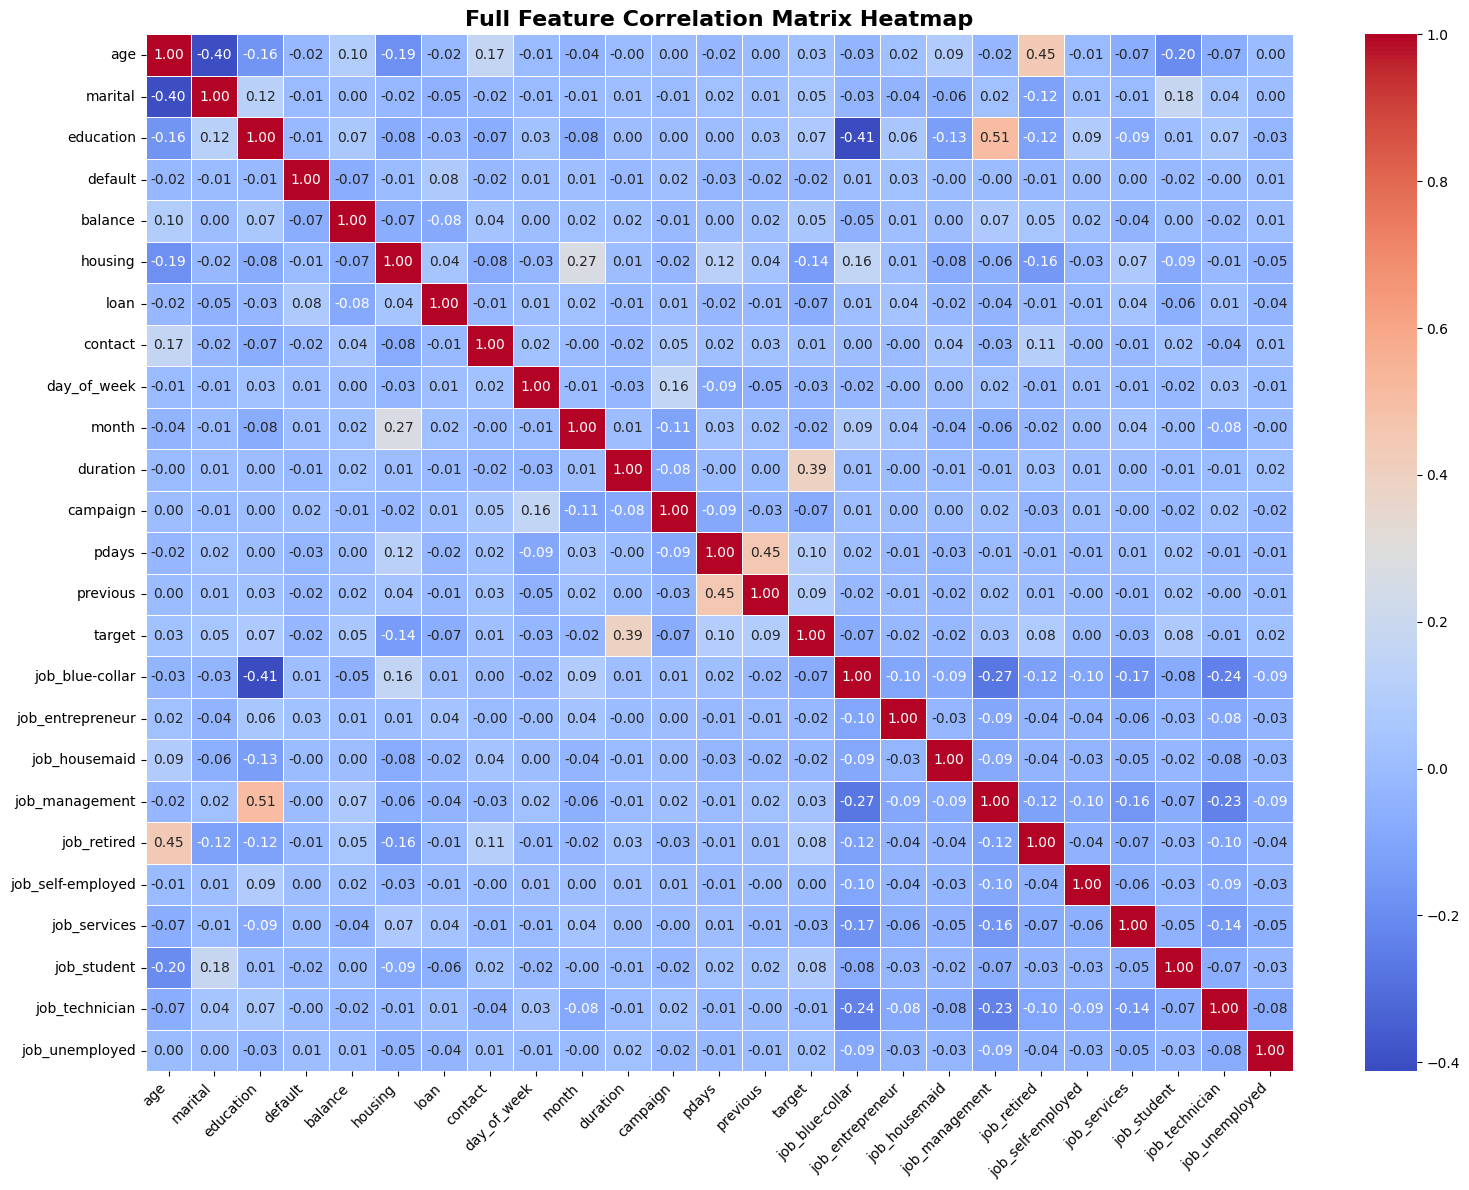

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the size of your visualization canvas
plt.figure(figsize=(16, 12))

# 2. Draw the heatmap
# - 'annot=True' writes the correlation numbers inside the boxes
# - 'fmt=".2f"' rounds those numbers to 2 decimal places
# - 'cmap="coolwarm"' makes positive correlations red and negative ones blue
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# 3. Add titles and adjust labels
plt.title('Full Feature Correlation Matrix Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Rotates text labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()

# 4. Display the plot
plt.show()


/tmp/ipykernel_2758/4090551924.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_correlation_sorted.values, y=target_correlation_sorted.index, palette="coolwarm")


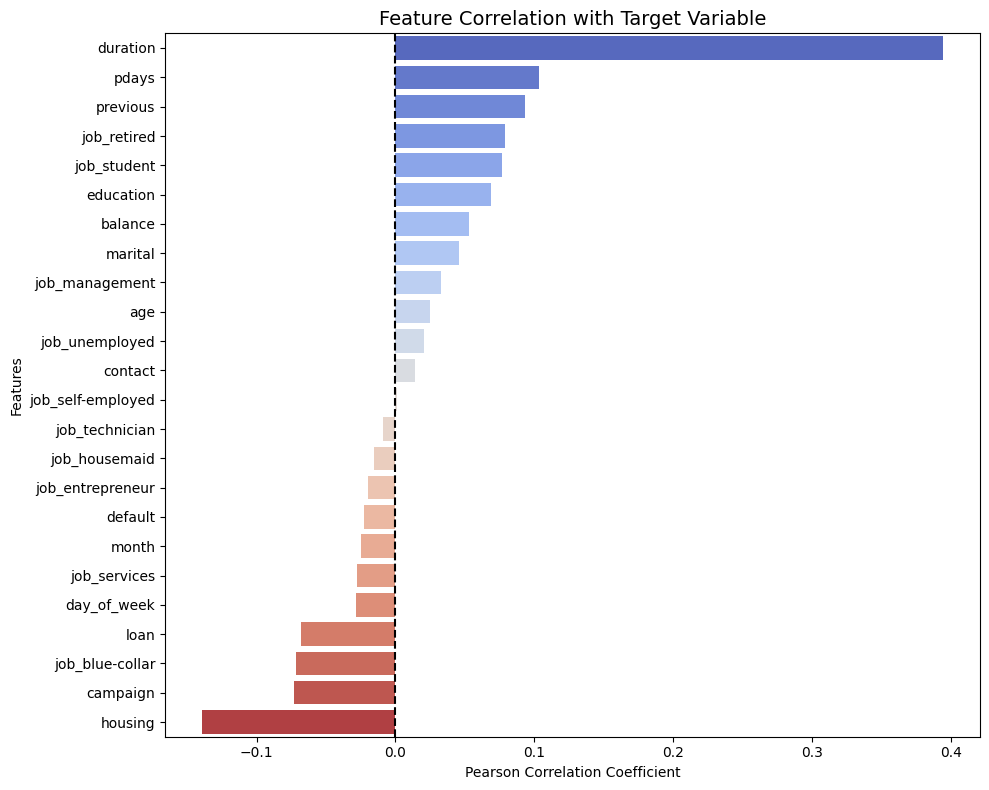

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
# Create the bar plot using sorted correlation values
sns.barplot(x=target_correlation_sorted.values, y=target_correlation_sorted.index, palette="coolwarm")

plt.axvline(x=0, color='black', linestyle='--') # Baseline center line
plt.title('Feature Correlation with Target Variable', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


In [ ]:
# Check min, max, and percentiles to spot extreme values
print(new_df[numerical_columns].describe())

                age        balance   day_of_week      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.

In [ ]:
numerical_columns = ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']

# Create a clean working copy
cleaned_df = new_df.copy()

for col in numerical_columns:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Clip values out of bounds to the threshold limits
    cleaned_df[col] = cleaned_df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers capped smoothly!")


Outliers capped smoothly!


In [ ]:
cleaned_df

,age,marital,education,default,balance,housing,loan,contact,day_of_week,month,...,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed
0,58.0,1,2,0,2143,1,0,0,5,8,...,0,0,0,1,0,0,0,0,0,0
1,44.0,2,1,0,29,1,0,0,5,8,...,0,0,0,0,0,0,0,0,1,0
2,33.0,1,1,0,2,1,1,0,5,8,...,0,1,0,0,0,0,0,0,0,0
3,47.0,1,1,0,1506,1,0,0,5,8,...,1,0,0,0,0,0,0,0,0,0
4,33.0,2,1,0,1,0,0,0,5,8,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51.0,1,2,0,825,0,0,0,17,9,...,0,0,0,0,0,0,0,0,1,0
45207,70.5,0,0,0,1729,0,0,0,17,9,...,0,0,0,0,1,0,0,0,0,0
45208,70.5,1,1,0,3462,0,0,0,17,9,...,0,0,0,0,1,0,0,0,0,0
45209,57.0,1,1,0,668,0,0,1,17,9,...,1,0,0,0,0,0,0,0,0,0


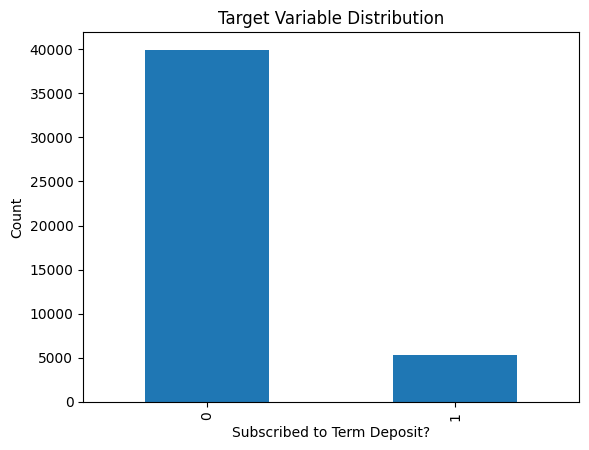

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Visualize the distribution
cleaned_df['target'].value_counts().plot(kind='bar')
plt.title('Target Variable Distribution')
plt.xlabel('Subscribed to Term Deposit?')
plt.ylabel('Count')
plt.show()

In [ ]:
pip install imbalanced-learn


In [ ]:
# 1. Define the exact name of your target column
target_col = "target"

# 2. Apply SMOTE by dropping the target column on the fly for X,
# and isolating the target column for y
X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(
    cleaned_df.drop(columns=[target_col]),
    cleaned_df[target_col]
)

# 3. Combine the balanced features and target back into a new DataFrame
balanced_df = pd.DataFrame(X_resampled)
balanced_df[target_col] = y_resampled

# 4. Verify the new, perfectly balanced distribution
print("SMOTE Completed Successfully!")
print(f"Original shape: {cleaned_df.shape}")
print(f"New balanced shape: {balanced_df.shape}")
print(f"\nBalanced Class Counts:\n{balanced_df[target_col].value_counts()}")


SMOTE Completed Successfully!
Original shape: (45211, 25)
New balanced shape: (79844, 25)

Balanced Class Counts:
target
0    39922
1    39922
Name: count, dtype: int64


In [ ]:
# SPLIT FIRST (Separate into training and testing datasets)
X = balanced_df.drop(columns=[target_col])
y = balanced_df[target_col]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Define ONLY your continuous numeric columns
continuous_features = ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
target_col = 'target'

# Initialize the StandardScaler
scaler = StandardScaler()

# Initialize the PCA component
pca = PCA(n_components=10, random_state=42) # Assuming 10 components based on your scree plot


# APPLY TO THE TRAIN SET
# A) Standardize ONLY the continuous columns in training data
X_train_scaled = X_train.copy()
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])

# B) Run PCA across ALL features in the training data
X_train_pca = pca.fit_transform(X_train_scaled)


# APPLY TO THE TEST SET (Using rules learned from Train Set)
# A) Transform test data using the TRAIN set's scale parameters
X_test_scaled = X_test.copy()
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])


# B) Project test data onto the TRAIN set's principal components
X_test_pca = pca.transform(X_test_scaled)

**Random Forest**

In [ ]:
# Initialize and train the Random Forest Model
random_forest_model = RandomForestClassifier(random_state=42, n_estimators=100)
random_forest_model.fit(X_train_pca, y_train)

# Generate predictions on the test set
y_predict = random_forest_model.predict(X_test_pca)

In [ ]:
#  Output the results
print("--- Classification Report ---")
print(classification_report(y_test, y_predict))

#Accuracy
print('---Baseline Accuracy---')
print(accuracy_score(y_test,y_predict))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_predict)
print(cm)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      7985
           1       0.89      0.91      0.90      7984

    accuracy                           0.90     15969
   macro avg       0.90      0.90      0.90     15969
weighted avg       0.90      0.90      0.90     15969

---Baseline Accuracy---
0.9032500469659966

--- Confusion Matrix ---
[[7123  862]
 [ 683 7301]]


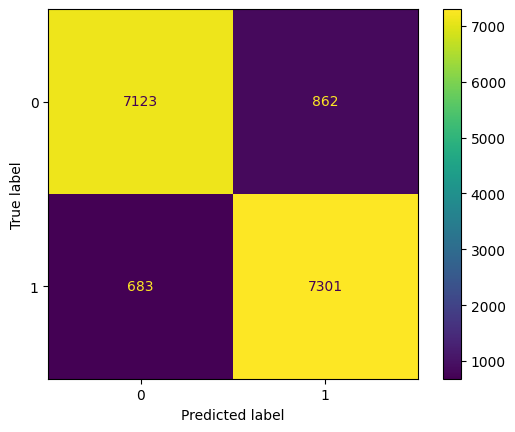

In [ ]:
dis = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=random_forest_model.classes_)
dis.plot()

In [ ]:
f1 = round(f1_score(y_test, y_predict),4)
print(f"F1 Score: {f1}")

F1 Score: 0.9043


In [ ]:
# Define feature arrays from your pre-SMOTE dataset
target_col = 'target'
continuous_features = ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']

# Isolate continuous scaling using a ColumnTransformer
# This ensures dummy columns are ignored during scaling
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), continuous_features)],
    remainder='passthrough'
)

# Assemble the pipeline steps in strict chronological order
pipeline = Pipeline(steps=[
    ('scaler', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

In [ ]:
# Fixed Parameter Space for Grid Search
grid_param_space = {
    'pca__n_components': [5, 10, 15],  # Now tuning PCA components simultaneously!
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None]
}


# Broader Distribution Space for Random Search
random_param_space = {
    'pca__n_components': [5, 10, 15, 20],
    'rf__n_estimators': [int(x) for x in np.linspace(50, 400, num=5)],
    'rf__max_depth': [10, 30, 50, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__max_features': ['sqrt', 'log2', None]
}


In [ ]:
# Train the baseline pipeline on the raw training split
base_rf = pipeline.fit(X_train, y_train)

# Make safe predictions on the raw test split
pred_rf = base_rf.predict(X_test)

# Print Performance Metrics
print('Baseline Accuracy: ', round(accuracy_score(y_test, pred_rf), 4))
print('Baseline F1: ', round(f1_score(y_test, pred_rf), 4))
print("\nClassification Report:")
print(classification_report(y_test, pred_rf))

# Calculate Stratified 5-Fold Cross Validation Score
# Use scoring='f1' to monitor balance instead of pure accuracy
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1', n_jobs=-1)
print(f'Cross Validation F1-Score = {cv_scores.mean():.4f}')

Baseline Accuracy:  0.9108
Baseline F1:  0.91

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      7985
           1       0.92      0.90      0.91      7984

    accuracy                           0.91     15969
   macro avg       0.91      0.91      0.91     15969
weighted avg       0.91      0.91      0.91     15969

Cross Validation F1-Score = 0.8439


In [ ]:
'''# Assuming you did a clean train_test_split on your original encoded data:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize Grid Search using the pipeline object
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=grid_param_space,
    cv=5,
    scoring='f1'
)

# Fit using your raw, un-SMOTEd training split
grid_search.fit(X_train, y_train)

print("--- Optimal Grid Search Settings ---")
print(grid_search.best_params_)

# Evaluate the best model on your untouched test data
# The pipeline automatically transforms your raw test data safely!
grid_predictions = grid_search.predict(X_test)
print("\n--- Pipeline Grid Search Performance ---")
print(classification_report(y_test, grid_predictions)) '''

'# Assuming you did a clean train_test_split on your original encoded data:\n# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)\n\n# Initialize Grid Search using the pipeline object\ngrid_search = GridSearchCV(\n    estimator=pipeline,\n    param_grid=grid_param_space,\n    cv=5,\n    scoring=\'f1\'\n)\n\n# Fit using your raw, un-SMOTEd training split\ngrid_search.fit(X_train, y_train)\n\nprint("--- Optimal Grid Search Settings ---")\nprint(grid_search.best_params_)\n\n# Evaluate the best model on your untouched test data\n# The pipeline automatically transforms your raw test data safely!\ngrid_predictions = grid_search.predict(X_test)\nprint("\n--- Pipeline Grid Search Performance ---")\nprint(classification_report(y_test, grid_predictions)) '

In [ ]:
'''# Initialize Random Search using the pipeline object
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=random_param_space,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit using your raw training split
random_search.fit(X_train, y_train)

print("--- Optimal Random Search Settings ---")
print(random_search.best_params_)

# Evaluate the best model on your untouched test data
random_predictions = random_search.predict(X_test)
print("\n--- Pipeline Random Search Performance ---")
print(classification_report(y_test, random_predictions))
'''

'# Initialize Random Search using the pipeline object\nrandom_search = RandomizedSearchCV(\n    estimator=pipeline,\n    param_distributions=random_param_space,\n    n_iter=10,\n    cv=5,\n    scoring=\'f1\',\n    random_state=42,\n    n_jobs=-1,\n    verbose=1\n)\n\n# Fit using your raw training split\nrandom_search.fit(X_train, y_train)\n\nprint("--- Optimal Random Search Settings ---")\nprint(random_search.best_params_)\n\n# Evaluate the best model on your untouched test data\nrandom_predictions = random_search.predict(X_test)\nprint("\n--- Pipeline Random Search Performance ---")\nprint(classification_report(y_test, random_predictions))\n'

**Logistic Regression**

In [ ]:
# Create the Logistic Regression Pipeline
# 'max_iter=1000' ensures the mathematical solver has enough time to converge
pipe_lr = Pipeline([
    ('scaler', preprocessor),
    ('pca', PCA(n_components=10, random_state=42)),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])


# Train the pipeline on the raw training split
base_lr = pipe_lr.fit(X_train, y_train)

# Make safe predictions on the raw test split
pred_lr = base_lr.predict(X_test)

# Print Performance Metrics
print('Logistic Regression Accuracy: ', round(accuracy_score(y_test, pred_lr), 4))
print('Logistic Regression F1-Score: ', round(f1_score(y_test, pred_lr), 4))
print("\nClassification Report:")
print(classification_report(y_test, pred_lr))

# Evaluate global stability using Stratified 5-Fold Cross Validation
cv_scores = cross_val_score(pipe_lr, X, y, cv=5, scoring='f1', n_jobs=-1)
print(f'Cross Validation F1-Score = {cv_scores.mean():.4f}')


Logistic Regression Accuracy:  0.8334
Logistic Regression F1-Score:  0.8369

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      7985
           1       0.82      0.86      0.84      7984

    accuracy                           0.83     15969
   macro avg       0.83      0.83      0.83     15969
weighted avg       0.83      0.83      0.83     15969

Cross Validation F1-Score = 0.8219



--- Confusion Matrix ---
[[6482 1503]
 [1157 6827]]


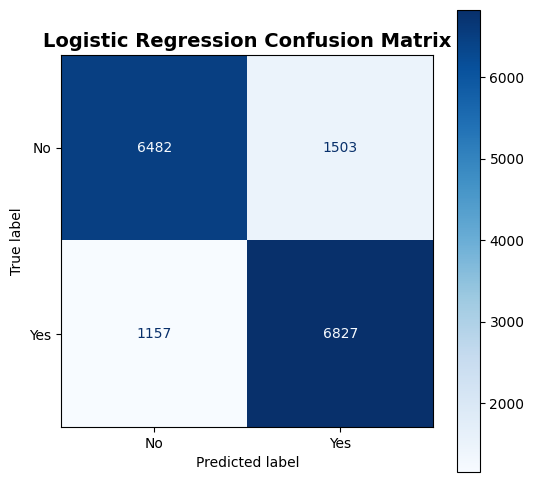

In [ ]:
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, pred_lr)
print(cm)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
#  Draw the matrix using a clean color map (cmap)
disp.plot(cmap='Blues', ax=ax, values_format='d')

# Add titles and show the chart
plt.title('Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold')
plt.grid(False) # Hides grid lines behind the blocks
plt.show()

**Decision Tree Classifier**

In [ ]:
# Create the DecisionTree Pipeline
# 'max_depth=5' provides a safe baseline to prevent immediate overfitting
pipe_dt = Pipeline([
    ('scaler', preprocessor),
    ('pca', PCA(n_components=10, random_state=42)),
    ('dt',  DecisionTreeClassifier(max_depth=5, random_state=42))
])


# Train the pipeline on the raw training split
base_dt = pipe_dt.fit(X_train, y_train)

# Make safe predictions on the raw test split
pred_dt = base_dt.predict(X_test)

# Print Performance Metrics
print('DecisionTree: ', round(accuracy_score(y_test, pred_dt), 4))
print('DecisionTree F1-Score: ', round(f1_score(y_test, pred_dt), 4))
print("\nClassification Report:")
print(classification_report(y_test, pred_dt))

# Evaluate global stability using Stratified 5-Fold Cross Validation
cv_scores = cross_val_score(pipe_dt, X, y, cv=5, scoring='f1', n_jobs=-1)
print(f'Cross Validation F1-Score = {cv_scores.mean():.4f}')


DecisionTree:  0.8098
DecisionTree F1-Score:  0.8152

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      7985
           1       0.79      0.84      0.82      7984

    accuracy                           0.81     15969
   macro avg       0.81      0.81      0.81     15969
weighted avg       0.81      0.81      0.81     15969

Cross Validation F1-Score = 0.7558


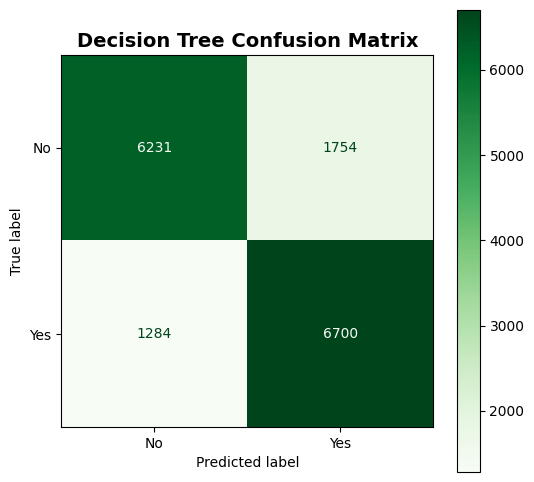

In [ ]:
# Generate the raw numerical confusion matrix array using your Decision Tree predictions
cm_dt = confusion_matrix(y_test, pred_dt)

# Set up the plotting canvas
fig, ax = plt.subplots(figsize=(6, 6))

# Initialize the visual display wrapper
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['No', 'Yes'])

# Draw the matrix using a clean color map (cmap)
# 'values_format="d"' ensures counts are displayed as regular integers
disp.plot(cmap='Greens', ax=ax, values_format='d')

# Clear up the formatting grid lines and add a title
plt.title('Decision Tree Confusion Matrix', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

**Support Vector Machine (SVM)**

In [ ]:
# Create the Support Vector Machine Pipeline
# 'kernel="rbf"' is the standard non-linear baseline (Radial Basis Function)
pipe_svm = Pipeline([
    ('scaler', preprocessor),
    ('pca', PCA(n_components=10, random_state=42)),
    ('svm', SVC(kernel='rbf', random_state=42))
])

# Train the pipeline on the raw training split
base_svm = pipe_svm.fit(X_train, y_train)

# Make safe predictions on the raw test split
pred_svm = base_svm.predict(X_test)

# Print Performance Metrics
print('SVM Accuracy: ', round(accuracy_score(y_test, pred_svm), 4))
print('SVM F1-Score: ', round(f1_score(y_test, pred_svm), 4))
print("\nClassification Report:")
print(classification_report(y_test, pred_svm))

# Evaluate global stability using Stratified 5-Fold Cross Validation
cv_scores = cross_val_score(pipe_svm, X, y, cv=5, scoring='f1', n_jobs=-1)
print(f'Cross Validation F1-Score = {cv_scores.mean():.4f}')


SVM Accuracy:  0.8675
SVM F1-Score:  0.8728

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.83      0.86      7985
           1       0.84      0.91      0.87      7984

    accuracy                           0.87     15969
   macro avg       0.87      0.87      0.87     15969
weighted avg       0.87      0.87      0.87     15969

Cross Validation F1-Score = 0.7781


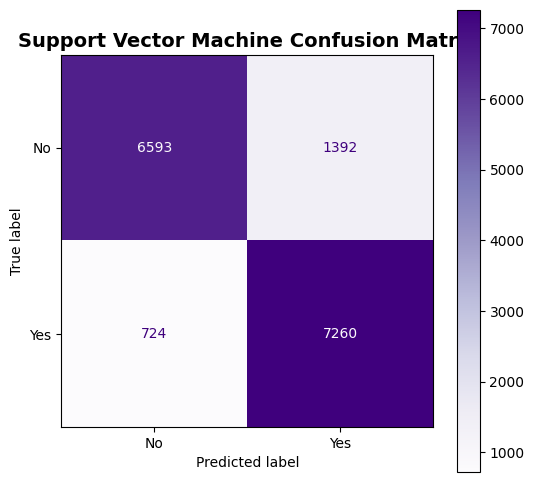

In [ ]:
# Generate the raw numerical confusion matrix array using Support Vector Machine (SVM) predictions
cm_svm = confusion_matrix(y_test, pred_svm)

# Set up the plotting canvas
fig, ax = plt.subplots(figsize=(6, 6))

# Initialize the visual display wrapper
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['No', 'Yes'])

# Draw the matrix using a clean color map (cmap)
# 'values_format="d"' ensures counts are displayed as regular integers
disp.plot(cmap='Purples', ax=ax, values_format='d')

# Clear up the formatting grid lines and add a title
plt.title('Support Vector Machine Confusion Matrix', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

**k-Nearest Neighbors (k-NN)**

In [ ]:
# Create the k-NN Pipeline
# 'n_neighbors=5' is the standard baseline entry point
pipe_knn = Pipeline([
    ('scaler', preprocessor),
    ('pca', PCA(n_components=10, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=2))
])


# Train the pipeline on the raw training split
base_knn = pipe_knn.fit(X_train, y_train)

# Make safe predictions on the raw test split
pred_knn = base_knn.predict(X_test)

# Print Performance Metrics
print('k-NN Accuracy: ', round(accuracy_score(y_test, pred_knn), 4))
print('k-NN F1-Score: ', round(f1_score(y_test, pred_knn), 4))
print("\nClassification Report:")
print(classification_report(y_test, pred_knn))

# Evaluate global stability using Stratified 5-Fold Cross Validation
cv_scores = cross_val_score(pipe_knn, X, y, cv=5, scoring='f1', n_jobs=-1)
print(f'Cross Validation F1-Score = {cv_scores.mean():.4f}')


k-NN Accuracy:  0.8665
k-NN F1-Score:  0.8609

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      7985
           1       0.90      0.83      0.86      7984

    accuracy                           0.87     15969
   macro avg       0.87      0.87      0.87     15969
weighted avg       0.87      0.87      0.87     15969

Cross Validation F1-Score = 0.7717


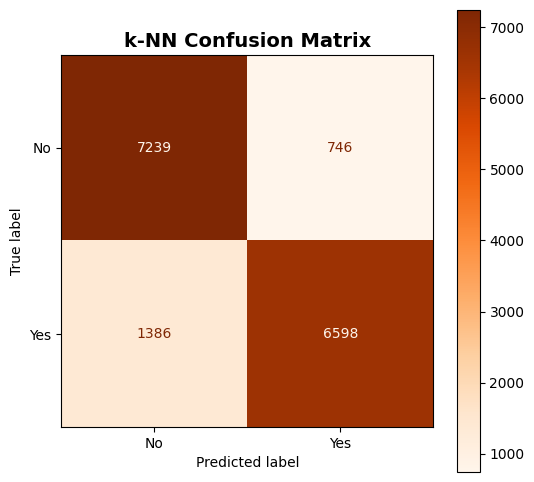

In [ ]:
#Generate the raw numerical confusion matrix array for k-NN
cm_knn = confusion_matrix(y_test, pred_knn)

# Set up the plotting canvas
fig, ax = plt.subplots(figsize=(6, 6))

# Initialize the visual display wrapper
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No', 'Yes'])

# Draw the matrix using an orange color map to distinguish it
disp.plot(cmap='Oranges', ax=ax, values_format='d')

# Clean up formatting and display
plt.title('k-NN Confusion Matrix', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

**Naive_bayes: GaussianNB**

In [ ]:
# Create the Gaussian Naive Bayes Pipeline
pipe_nb = Pipeline([
    ('scaler', preprocessor),
    ('pca', PCA(n_components=10, random_state=42)),
    ('nb', GaussianNB())
])

# Train the pipeline on the raw training split
base_nb = pipe_nb.fit(X_train, y_train)

# Make safe predictions on the raw test split
pred_nb = base_nb.predict(X_test)

# Print Performance Metrics
print('Naive Bayes Accuracy: ', round(accuracy_score(y_test, pred_nb), 4))
print('Naive Bayes F1-Score: ', round(f1_score(y_test, pred_nb), 4))
print("\nClassification Report:")
print(classification_report(y_test, pred_nb))

# Evaluate global stability using Stratified 5-Fold Cross Validation
cv_scores = cross_val_score(pipe_nb, X, y, cv=5, scoring='f1', n_jobs=-1)
print(f'Cross Validation F1-Score = {cv_scores.mean():.4f}')


Naive Bayes Accuracy:  0.8259
Naive Bayes F1-Score:  0.8281

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      7985
           1       0.82      0.84      0.83      7984

    accuracy                           0.83     15969
   macro avg       0.83      0.83      0.83     15969
weighted avg       0.83      0.83      0.83     15969

Cross Validation F1-Score = 0.8080


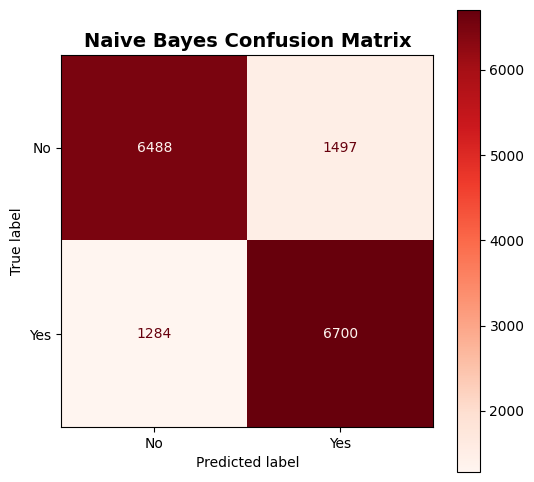

In [ ]:
# Generate the raw numerical confusion matrix array for Naive Bayes
cm_nb = confusion_matrix(y_test, pred_nb)

# Set up the plotting canvas
fig, ax = plt.subplots(figsize=(6, 6))

# Initialize the visual display wrapper
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['No', 'Yes'])

# Draw the matrix using a clean pink/red map to distinguish it from others
disp.plot(cmap='Reds', ax=ax, values_format='d')

# Clean up formatting and display
plt.title('Naive Bayes Confusion Matrix', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

In [ ]:
models = {
    'RandomForest': base_rf,
    'DecisionTree': base_dt,
    'SVM': base_svm,
    'KNN': base_knn,
    'NaiveBayes': base_nb
}

results = []
for n, m in models.items():
    # Always generate predictions on X_test to match y_test
    p = m.predict(X_test)

    # SVM does not support predict_proba by default.
    # This block safely extracts decision paths or fallback arrays to prevent crashes.
    if hasattr(m, "predict_proba"):
        prob = m.predict_proba(X_test)[:, 1]
    elif hasattr(m, "decision_function"):
        prob = m.decision_function(X_test)
    else:
        prob = p # Fallback directly to hard predictions if required

    # Calculate metrics using matching test array shapes
    acc = accuracy_score(y_test, p)
    f1 = f1_score(y_test, p)
    auc = float(roc_auc_score(y_test, prob))

    results.append((n, acc, f1, auc))

# Generate summary table
df_results = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1-Score', 'ROC-AUC'])
print(df_results.to_string(index=False))

# Select absolute best model using F1-score as primary and AUC as tie-breaker
best = max(results, key=lambda x: (x[2], x[3]))
print('\nAbsolute Best Model:', best[0])


       Model  Accuracy  F1-Score  ROC-AUC
RandomForest  0.910765  0.909987 0.970911
DecisionTree  0.809756  0.815184 0.877056
         SVM  0.867493  0.872806 0.939574
         KNN  0.866491  0.860908 0.914928
  NaiveBayes  0.825850  0.828132 0.897948

Absolute Best Model: RandomForest
